<a href="https://colab.research.google.com/github/Andrea-24744/Procesos-Est-casticos-/blob/main/MEDEL_actividad_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

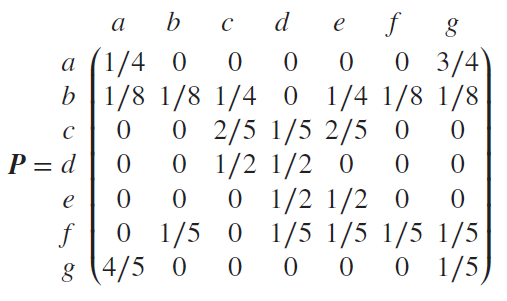

In [2]:
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt
P = sp.Matrix([
    [1/4,0,0,0,0,0,3/4],
    [1/8,1/8,1/4,0,1/4,1/8,1/8],
    [0,0,2/5,1/5,2/5,0,0],
    [0,0,1/2,1/2,0,0,0],
    [0,0,0,1/2,1/2,0,0],
    [0,1/5,0,1/5,1/5,1/5,1/5],
    [4/5,0,0,0,0,0,1/5]
])
sp.pprint(P)

⎡0.25     0     0     0    0      0    0.75 ⎤
⎢                                           ⎥
⎢0.125  0.125  0.25   0   0.25  0.125  0.125⎥
⎢                                           ⎥
⎢  0      0    0.4   0.2  0.4     0      0  ⎥
⎢                                           ⎥
⎢  0      0    0.5   0.5   0      0      0  ⎥
⎢                                           ⎥
⎢  0      0     0    0.5  0.5     0      0  ⎥
⎢                                           ⎥
⎢  0     0.2    0    0.2  0.2    0.2    0.2 ⎥
⎢                                           ⎥
⎣ 0.8     0     0     0    0      0     0.2 ⎦


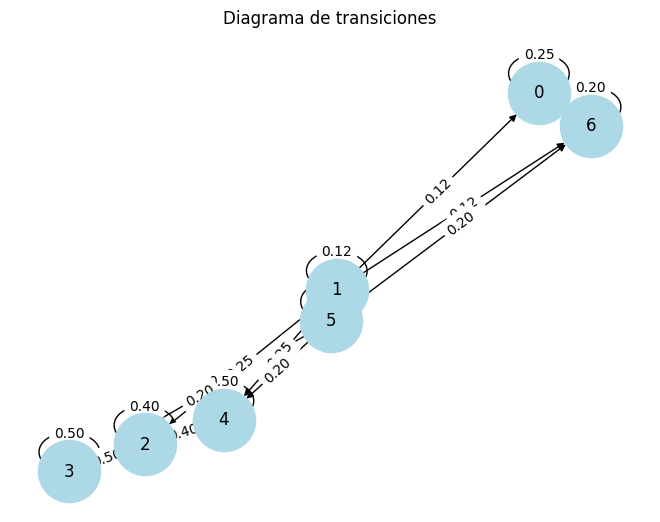

In [3]:
#Diagrama de transiciòn

states = ['a','b','c','d','e','f','g']

# ============================================================
# GRAFO DE TRANSICIONES
# ============================================================

def dibujar_grafo(P):
    n = P.shape[0]
    G = nx.DiGraph()

    for i in range(n):
        for j in range(n):
            if P[i, j] != 0:
                G.add_edge(i, j, weight=float(P[i, j]))

    pos = nx.spring_layout(G, seed=42)

    etiquetas = {(i, j): f"{float(P[i,j]):.2f}" for i, j in G.edges()}

    nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightblue")
    nx.draw_networkx_edge_labels(G, pos, edge_labels=etiquetas)

    plt.title("Diagrama de transiciones")
    plt.show()

dibujar_grafo(P)

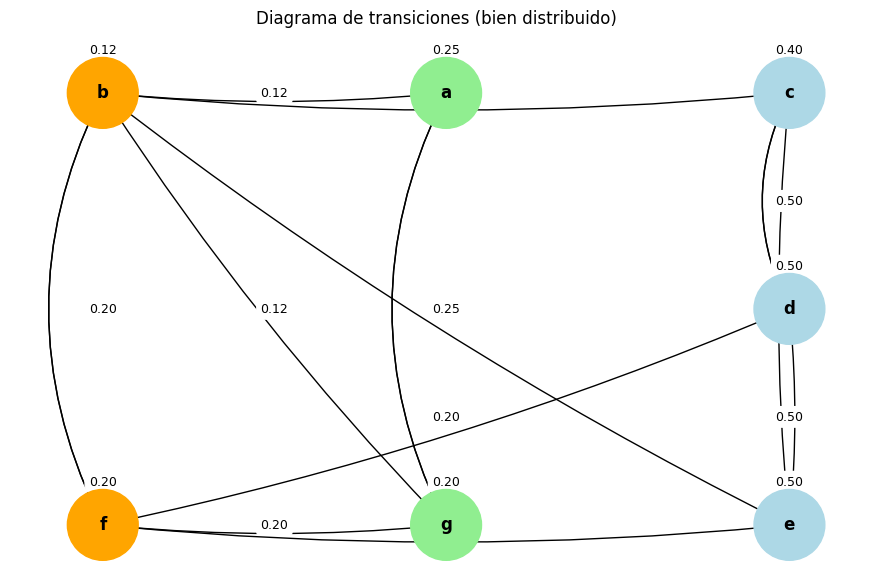

In [17]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

states = ['a','b','c','d','e','f','g']

P = np.array([
    [1/4, 0,   0,   0,   0,   0,   3/4],
    [1/8, 1/8, 1/4, 0,   1/4, 1/8, 1/8],
    [0,   0,   2/5, 1/5, 2/5, 0,   0],
    [0,   0,   1/2, 1/2, 0,   0,   0],
    [0,   0,   0,   1/2, 1/2, 0,   0],
    [0,   1/5, 0,   1/5, 1/5, 1/5, 1/5],
    [4/5, 0,   0,   0,   0,   0,   1/5]
])

G = nx.DiGraph()

# Construir grafo
for i in range(7):
    for j in range(7):
        if P[i, j] != 0:
            G.add_edge(states[i], states[j], weight=P[i, j])

# Posiciones (las tuyas están bien 👍)
pos = {
    'b': (-2, 1),
    'f': (-2, -1),
    'a': (0, 1),
    'g': (0, -1),
    'c': (2, 1),
    'd': (2, 0),
    'e': (2, -1),
}

# Colores por tipo
color_map = []
for node in G.nodes():
    if node in ['b','f']:
        color_map.append('orange')
    elif node in ['a','g']:
        color_map.append('lightgreen')
    else:
        color_map.append('lightblue')

plt.figure(figsize=(11,7))

# Nodos
nx.draw_networkx_nodes(G, pos, node_size=2600, node_color=color_map)
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

# ============================
# ARISTAS MEJORADAS
# ============================

for (u, v, d) in G.edges(data=True):

    if u == v:
        # loop
        nx.draw_networkx_edges(
            G, pos,
            edgelist=[(u, v)],
            connectionstyle="arc3,rad=0.4",
            arrows=True,
            arrowsize=20
        )
    elif (v, u) in G.edges():
        # bidireccional → separarlas
        rad = 0.25 if u < v else -0.25
        nx.draw_networkx_edges(
            G, pos,
            edgelist=[(u, v)],
            connectionstyle=f"arc3,rad={rad}",
            arrows=True,
            arrowsize=20
        )
    else:
        # normal
        nx.draw_networkx_edges(
            G, pos,
            edgelist=[(u, v)],
            connectionstyle="arc3,rad=0.05",
            arrows=True,
            arrowsize=20
        )

# ============================
# ETIQUETAS MEJOR POSICIONADAS
# ============================

edge_labels = {}
for (u, v, d) in G.edges(data=True):
    edge_labels[(u, v)] = f"{d['weight']:.2f}"

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=9,
    label_pos=0.5,   # centro de la arista
    rotate=False     # evita que giren feo
)

plt.title("Diagrama de transiciones (bien distribuido)")
plt.axis('off')
plt.show()

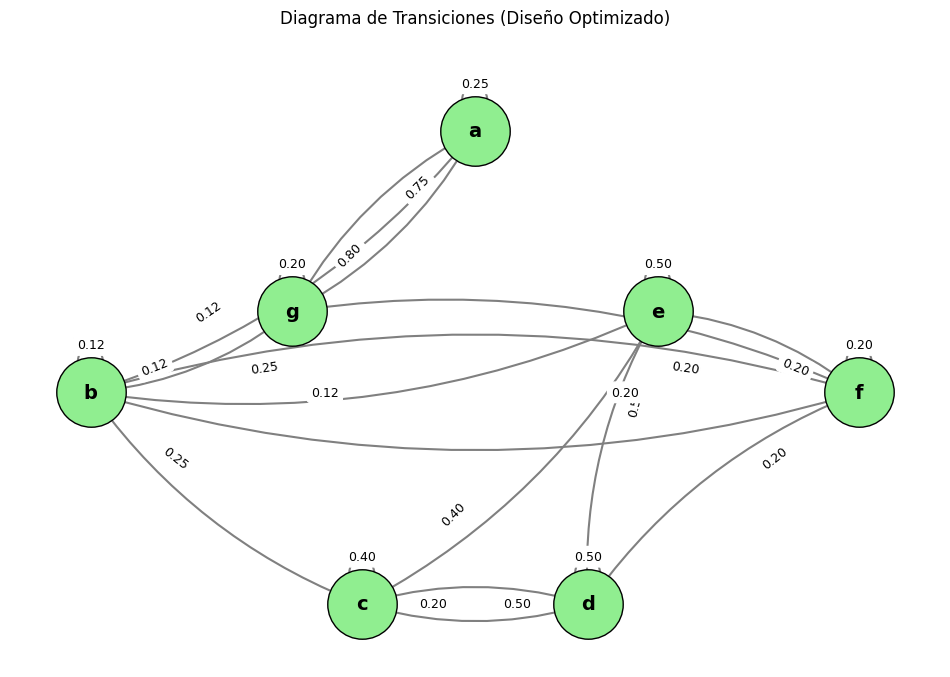

In [34]:
# Visualización del diagrama de transiciones
estados = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
def dibujar_grafo_limpio(matriz, etiquetas):
    G = nx.DiGraph()
    for i in range(len(etiquetas)):
        for j in range(len(etiquetas)):
            if matriz[i][j] > 0:
                G.add_edge(etiquetas[i], etiquetas[j], weight=matriz[i][j])

    # --- MEJORA DE DISEÑO ---
    # Usamos shell_layout para organizar los nodos en círculos concéntricos
    # Ponemos los transitorios (b, f) afuera y los recurrentes adentro
    pos = nx.shell_layout(G, nlist=[['a', 'g', 'c', 'd', 'e'], ['b', 'f']])

    plt.figure(figsize=(12, 8))

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_size=2500, node_color='lightgreen', edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=14, font_family='sans-serif', font_weight='bold')

    # Dibujar flechas con curvatura para que las de ida y vuelta no se tapen
    nx.draw_networkx_edges(G, pos, arrowstyle='->', arrowsize=25,
                           edge_color='gray', width=1.5,
                           connectionstyle='arc3, rad=0.15') # Curvatura clave

    # Añadir pesos (opcional, si se ve muy lleno puedes comentarlo)
    edge_labels = {(u, v): f'{d["weight"]:.2f}' for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, label_pos=0.3)

    plt.title("Diagrama de Transiciones (Diseño Optimizado)", pad=20)
    plt.axis('off')
    plt.show()

dibujar_grafo_limpio(P, estados)

In [4]:
# ============================================================
# DISTRIBUCIÓN ESTACIONARIA
# ============================================================

def distribucion_estacionaria(P):
    n = P.shape[0]
    pi = sp.symbols(f'p0:{n}')

    ecuaciones = []

    # πP = π
    for j in range(n):
        ecuaciones.append(sum(pi[i]*P[i,j] for i in range(n)) - pi[j])

    # suma = 1
    ecuaciones.append(sum(pi) - 1)

    sol = sp.solve(ecuaciones, pi)

    return sol

pi = distribucion_estacionaria(P)

print("Distribución estacionaria:")
sp.pprint(pi)



Distribución estacionaria:
{p₀: 1.06666666666667⋅p₆, p₁: 0.0, p₂: 0.333333333333333 - 0.688888888888889⋅p ↪

↪ ₆, p₃: 0.4 - 0.826666666666667⋅p₆, p₄: 0.266666666666667 - 0.551111111111111 ↪

↪ ⋅p₆, p₅: 0.0}


In [5]:
# ============================================================
# CLASES DE COMUNICACIÓN
# ============================================================

def clases_comunicacion(P):
    G = nx.DiGraph()

    n = P.shape[0]
    for i in range(n):
        for j in range(n):
            if P[i,j] != 0:
                G.add_edge(i, j)

    return list(nx.strongly_connected_components(G))

clases = clases_comunicacion(P)

print("Clases de comunicación:")
print(clases)

Clases de comunicación:
[{0, 6}, {2, 3, 4}, {1, 5}]


In [11]:
# ============================================================
# CLASIFICACIÓN DE ESTADOS
# ============================================================

def es_cerrada(P, clase):
    for i in clase:
        for j in range(P.shape[0]):
            if j not in clase and P[i,j] != 0:
                return False
    return True

cerradas = []
transientes = []

for clase in clases:
    if es_cerrada(P, clase):
        cerradas.append(list(clase))
    else:
        transientes.extend(list(clase))

print("Clases cerradas:", cerradas)
print("Estados transientes:", transientes)

Clases cerradas: [[0, 6], [2, 3, 4]]
Estados transientes: [1, 5]


In [12]:
# ============================================================
# FORMA CANÓNICA
# ============================================================

orden = transientes + [i for clase in cerradas for i in clase]

P_canonica = P.extract(orden, orden)

print("Orden de estados:", orden)
print("Matriz canónica:")
sp.pprint(P_canonica)

Orden de estados: [1, 5, 0, 6, 2, 3, 4]
Matriz canónica:
⎡0.125  0.125  0.125  0.125  0.25   0   0.25⎤
⎢                                           ⎥
⎢ 0.2    0.2     0     0.2    0    0.2  0.2 ⎥
⎢                                           ⎥
⎢  0      0    0.25   0.75    0     0    0  ⎥
⎢                                           ⎥
⎢  0      0     0.8    0.2    0     0    0  ⎥
⎢                                           ⎥
⎢  0      0      0      0    0.4   0.2  0.4 ⎥
⎢                                           ⎥
⎢  0      0      0      0    0.5   0.5   0  ⎥
⎢                                           ⎥
⎣  0      0      0      0     0    0.5  0.5 ⎦


In [13]:
# ============================================================
# BLOQUES
# ============================================================

t = len(transientes)

Q = P_canonica[:t, :t]
R = P_canonica[:t, t:]
S = P_canonica[t:, t:]

print("Q:")
sp.pprint(Q)

print("R:")
sp.pprint(R)

print("S:")
sp.pprint(S)

Q:
⎡0.125  0.125⎤
⎢            ⎥
⎣ 0.2    0.2 ⎦
R:
⎡0.125  0.125  0.25   0   0.25⎤
⎢                             ⎥
⎣  0     0.2    0    0.2  0.2 ⎦
S:
⎡0.25  0.75   0    0    0 ⎤
⎢                         ⎥
⎢0.8   0.2    0    0    0 ⎥
⎢                         ⎥
⎢ 0     0    0.4  0.2  0.4⎥
⎢                         ⎥
⎢ 0     0    0.5  0.5   0 ⎥
⎢                         ⎥
⎣ 0     0     0   0.5  0.5⎦


In [14]:
# ============================================================
# POTENCIA DE LA MATRIZ
# ============================================================

Pn = P**50   # grande para aproximar límite

print("P^n:")
sp.pprint(Pn.evalf())

P^n:
⎡0.516129032258116           0                    0                  0         ↪
⎢                                                                              ↪
⎢0.172043010752686  1.51075729836657e-25  0.222222222222222  0.266666666666667 ↪
⎢                                                                              ↪
⎢        0                   0            0.333333333333333         0.4        ↪
⎢                                                                              ↪
⎢        0                   0            0.333333333333333         0.4        ↪
⎢                                                                              ↪
⎢        0                   0            0.333333333333334         0.4        ↪
⎢                                                                              ↪
⎢0.172043010752703  2.41721167738652e-25  0.222222222222222  0.266666666666667 ↪
⎢                                                                              ↪
⎣0.516129032258012     

In [15]:
# ============================================================
# DISTRIBUCIÓN EN S
# ============================================================

if S.shape[0] > 0:
    pi_S = distribucion_estacionaria(S)
    print("Distribución en S:")
    sp.pprint(pi_S)

Distribución en S:
{p₀: 0.516129032258065 - 1.93548387096774⋅p₄, p₁: 0.483870967741935 - 1.814516 ↪

↪ 12903226⋅p₄, p₂: 1.25⋅p₄, p₃: 1.5⋅p₄}


In [16]:
# ============================================================
# DESCOMPOSICIÓN CANÓNICA GENERAL
# ============================================================

def descomposicion_canonica(P):
    n = P.shape[0]
    G = nx.DiGraph()

    for i in range(n):
        for j in range(n):
            if P[i,j] != 0:
                G.add_edge(i, j)

    clases = list(nx.strongly_connected_components(G))

    def es_cerrada(clase):
        for i in clase:
            for j in range(n):
                if j not in clase and P[i,j] != 0:
                    return False
        return True

    cerradas = []
    transientes = []

    for clase in clases:
        if es_cerrada(clase):
            cerradas.append(list(clase))
        else:
            transientes.extend(list(clase))

    orden = transientes + [i for clase in cerradas for i in clase]
    P_canonica = P.extract(orden, orden)

    t = len(transientes)

    return {
        "orden": orden,
        "P_canonica": P_canonica,
        "Q": P_canonica[:t, :t],
        "R": P_canonica[:t, t:],
        "S": P_canonica[t:, t:],
        "transientes": transientes,
        "cerradas": cerradas
    }

# Ejemplo
resultado = descomposicion_canonica(P)

for k, v in resultado.items():
    print(f"\n{k}:")
    sp.pprint(v)


orden:
[1, 5, 0, 6, 2, 3, 4]

P_canonica:
⎡0.125  0.125  0.125  0.125  0.25   0   0.25⎤
⎢                                           ⎥
⎢ 0.2    0.2     0     0.2    0    0.2  0.2 ⎥
⎢                                           ⎥
⎢  0      0    0.25   0.75    0     0    0  ⎥
⎢                                           ⎥
⎢  0      0     0.8    0.2    0     0    0  ⎥
⎢                                           ⎥
⎢  0      0      0      0    0.4   0.2  0.4 ⎥
⎢                                           ⎥
⎢  0      0      0      0    0.5   0.5   0  ⎥
⎢                                           ⎥
⎣  0      0      0      0     0    0.5  0.5 ⎦

Q:
⎡0.125  0.125⎤
⎢            ⎥
⎣ 0.2    0.2 ⎦

R:
⎡0.125  0.125  0.25   0   0.25⎤
⎢                             ⎥
⎣  0     0.2    0    0.2  0.2 ⎦

S:
⎡0.25  0.75   0    0    0 ⎤
⎢                         ⎥
⎢0.8   0.2    0    0    0 ⎥
⎢                         ⎥
⎢ 0     0    0.4  0.2  0.4⎥
⎢                         ⎥
⎢ 0     0    0.5  0.5   0 ⎥
⎢         